### 3) Representación Laplaciana de Imágenes de Fase de RM

#### 3.1) Extensión a 3D (5 puntos)

Se agregaran las funciones que se extienden a 3D, utilizando el mismo filtro que se vio en clases. 

In [ ]:
# !pip install nibabel
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

In [59]:
base_path = os.getcwd()
base_path = '/home/chr/phd/IEE3787/Tareas/T1'

In [60]:
def conv_3d(vol, kernel):
    return convolve(vol, kernel, mode='reflect')


def expand_3d(vol, func):
    d, h, w = vol.shape
    expanded = np.zeros((d * 2, h * 2, w * 2), dtype=np.float64)
    expanded[::2, ::2, ::2] = vol
    return func(expanded) * 8.0

def reconstruct_3d(laplacian_pyramid, func):
    vol = laplacian_pyramid[-1] 
    for l in laplacian_pyramid[::-1][1:]:
        exp_vol = expand_3d(vol, func)
        d, h, w = l.shape
        exp_vol = exp_vol[:d, :h, :w] # recortar para igualar dimensiones
        vol = exp_vol + l 
        
    return vol

def gaussian_pyramid_3d(func, vol, levels):
    pyramid = [vol]
    blurred = []
    for _ in range(levels):
        blur = func(pyramid[-1])
        blurred.append(blur)
        pyramid.append(blur[::2, ::2, ::2])
        
    return pyramid, blurred

def laplacian_pyramid_3d(gaussian_pyr, func):
    laplacian_pyr = []
    for i in range(len(gaussian_pyr) - 1):
        vol = gaussian_pyr[i]
        vol_down = gaussian_pyr[i+1]
        
        exp_vol = expand_3d(vol_down, func)
        d, h, w = vol.shape
        exp_vol = exp_vol[:d, :h, :w]
        
        laplacian = vol - exp_vol
        laplacian_pyr.append(laplacian)
        
    laplacian_pyr.append(gaussian_pyr[-1]) # residual
    return laplacian_pyr

In [115]:
def show_pyramid_3d(pyramid, title, nivel=True):
    fig, axes = plt.subplots(1, len(pyramid), figsize=(15, 5))
    fig.suptitle(title, fontsize=16, y=0.9)
    
    for i, (ax, vol) in enumerate(zip(axes, pyramid)):
        mid_slice = vol.shape[0] // 2
        ax.imshow(vol[mid_slice], cmap='gray', interpolation='none')
        if nivel:
            ax.set_title(f"Nivel {i}")
        ax.axis('off')
    
    plt.tight_layout()
    plt.colorbar(axes[0].images[0], ax=axes, fraction=0.02, pad=0.04)
    plt.show()

In [76]:
def gaussian_kernel_3d(size, sigma):
    ax = np.arange(-(size//2), size//2 + 1)
    xx, yy, zz = np.meshgrid(ax, ax, ax)
    kernel = np.exp(-(xx**2 + yy**2 + zz**2) / (2 * sigma**2))
    return kernel / kernel.sum()

def bin_kernel_3d(n):
    if n == 3:
        bk = np.array([1, 2, 1]) / 4.0
    elif n == 5:
        bk = np.array([1, 4, 6, 4, 1]) / 16.0
    k3d = bk[:, None, None] * bk[None, :, None] * bk[None, None, :]
    return k3d

In [77]:
total = base_path + '/Clase1_material/unwrapped_seguetotalphase.nii'
volumen = nib.load(total).get_fdata()

local = base_path + '/Clase1_material/unwrapped_truelocalphase.nii'
vsharp = base_path + '/Clase1_material/local_vsharp_m4.nii'
mask = base_path + '/Clase1_material/mask4.nii'

In [93]:
def show_nii(path_file):
    img = nib.load(path_file)
    volumen = img.get_fdata()

    print("------- Información -------")
    print(f"Dimensión: {volumen.shape}")
    print(f"Tipo de dato: {volumen.dtype}")
    print(f"Valores mínimo y máximo: {volumen.min()}, {volumen.max()}")

    if volumen.ndim == 4:
        print(f"Dimensión temporal: {volumen.shape[3]}")
        volumen = volumen[..., 0]  # Tomar el primer volumen si hay dimensión temporal

    x_mid, y_mid, z_mid = np.array(volumen.shape) // 2

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(volumen[x_mid, :, :], cmap='gray', origin='lower')
    axes[0].axis('off')

    axes[1].imshow(volumen[:, y_mid, :], cmap='gray', origin='lower')
    axes[1].axis('off')

    axes[2].imshow(volumen[:, :, z_mid], cmap='gray', origin='lower')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

------- Información -------
Dimensión: (164, 205, 205)
Tipo de dato: float64
Valores mínimo y máximo: -83.77690134051623, 85.64779938068881


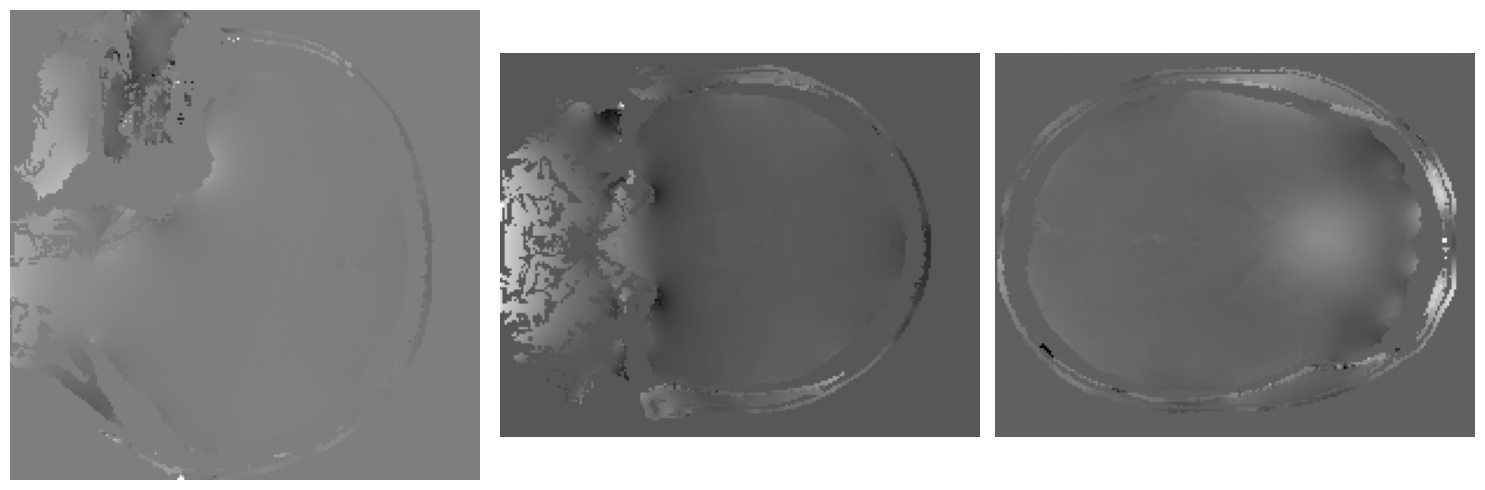

In [94]:
show_nii(total)

#### 3.2) Análisis de componentes armónicas vs. no armónicas (10 puntos)

In [80]:
fase_total = nib.load(total).get_fdata()
fase_local = nib.load(local).get_fdata()
fase_vsharp = nib.load(vsharp).get_fdata()
mask = nib.load(mask).get_fdata().astype(bool)

In [87]:
fase_fondo = fase_total - fase_local

print("Fase total  shape:", fase_total.shape)
print("Fase local  shape:", fase_local.shape)
print("Fase fondo  shape:", fase_fondo.shape)

Fase total  shape: (164, 205, 205)
Fase local  shape: (164, 205, 205)
Fase fondo  shape: (164, 205, 205)


In [84]:
LEVELS = 4

k_3x3_avg_3d = np.ones((3,3,3)) / 27
k_5x5_avg_3d = np.ones((5,5,5)) / 125
k_3x3_sig_1_3d = gaussian_kernel_3d(3, 1)
k_3x3_sig_2_3d = gaussian_kernel_3d(3, 2)
k_5x5_sig_1_3d = gaussian_kernel_3d(5, 1)
k_5x5_sig_2_3d = gaussian_kernel_3d(5, 2)
k_bin_3_3d = bin_kernel_3d(3)
k_bin_5_3d = bin_kernel_3d(5)

conv_3x3_avg_3d = lambda vol: conv_3d(vol, k_3x3_avg_3d)
conv_5x5_avg_3d = lambda vol: conv_3d(vol, k_5x5_avg_3d)
conv_3x3_s1_3d = lambda vol: conv_3d(vol, k_3x3_sig_1_3d)
conv_3x3_s2_3d = lambda vol: conv_3d(vol, k_3x3_sig_2_3d)
conv_5x5_s1_3d = lambda vol: conv_3d(vol, k_5x5_sig_1_3d)
conv_5x5_s2_3d = lambda vol: conv_3d(vol, k_5x5_sig_2_3d)
conv_bin_3_3d = lambda vol: conv_3d(vol, k_bin_3_3d)
conv_bin_5_3d = lambda vol: conv_3d(vol, k_bin_5_3d)

# laplacian pyramid 3d
lp_avg_3x3_3d = laplacian_pyramid_3d(gaussian_pyramid_3d(func=conv_3x3_avg_3d, vol=volumen, levels=LEVELS)[0], conv_3x3_avg_3d)
lp_avg_5x5_3d = laplacian_pyramid_3d(gaussian_pyramid_3d(func=conv_5x5_avg_3d, vol=volumen, levels=LEVELS)[0], conv_5x5_avg_3d)
lp_gs_3x3_s1_3d = laplacian_pyramid_3d(gaussian_pyramid_3d(func=conv_3x3_s1_3d, vol=volumen, levels=LEVELS)[0], conv_3x3_s1_3d)
lp_gs_3x3_s2_3d = laplacian_pyramid_3d(gaussian_pyramid_3d(func=conv_3x3_s2_3d, vol=volumen, levels=LEVELS)[0], conv_3x3_s2_3d)
lp_gs_5x5_s1_3d = laplacian_pyramid_3d(gaussian_pyramid_3d(func=conv_5x5_s1_3d, vol=volumen, levels=LEVELS)[0], conv_5x5_s1_3d)
lp_gs_5x5_s2_3d = laplacian_pyramid_3d(gaussian_pyramid_3d(func=conv_5x5_s2_3d, vol=volumen, levels=LEVELS)[0], conv_5x5_s2_3d)
lp_bin_3_3d = laplacian_pyramid_3d(gaussian_pyramid_3d(func=conv_bin_3_3d, vol=volumen, levels=LEVELS)[0], conv_bin_3_3d)
lp_bin_5_3d = laplacian_pyramid_3d(gaussian_pyramid_3d(func=conv_bin_5_3d, vol=volumen, levels=LEVELS)[0], conv_bin_5_3d)


lp_pyramids_3d = [
    ("AVG 3x3", lp_avg_3x3_3d, conv_3x3_avg_3d),
    ("AVG 5x5", lp_avg_5x5_3d, conv_5x5_avg_3d),
    ("Gauss 3x3 s1", lp_gs_3x3_s1_3d, conv_3x3_s1_3d),
    ("Gauss 3x3 s2", lp_gs_3x3_s2_3d, conv_3x3_s2_3d),
    ("Gauss 5x5 s1", lp_gs_5x5_s1_3d, conv_5x5_s1_3d),
    ("Gauss 5x5 s2", lp_gs_5x5_s2_3d, conv_5x5_s2_3d),
    ("Binomial 3x3", lp_bin_3_3d, conv_bin_3_3d),
    ("Binomial 5x5", lp_bin_5_3d, conv_bin_5_3d),
]

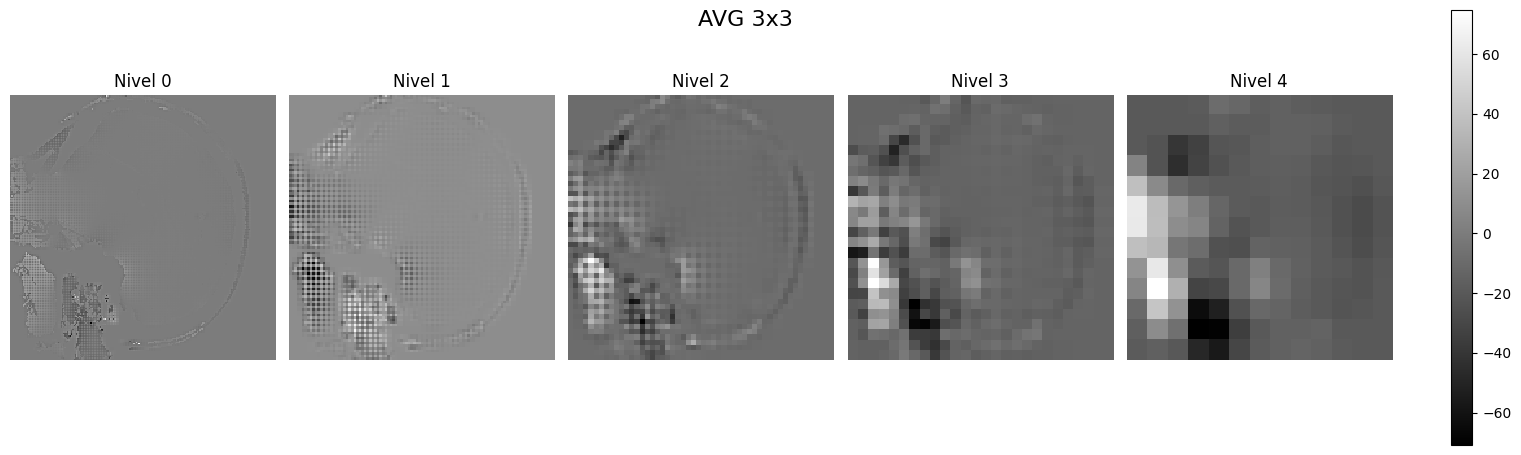

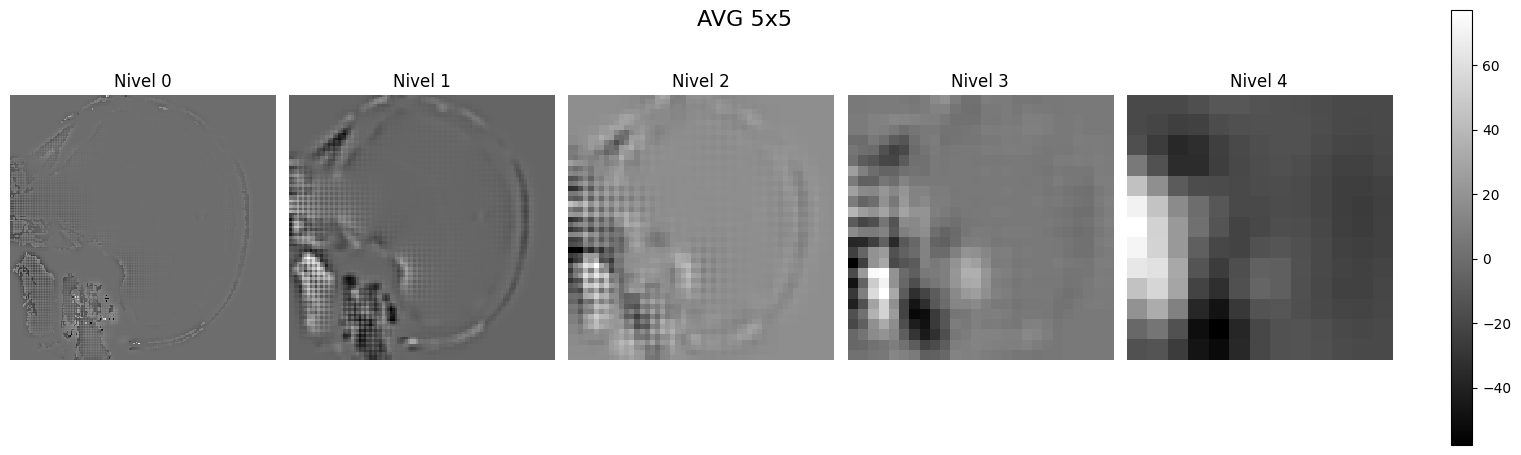

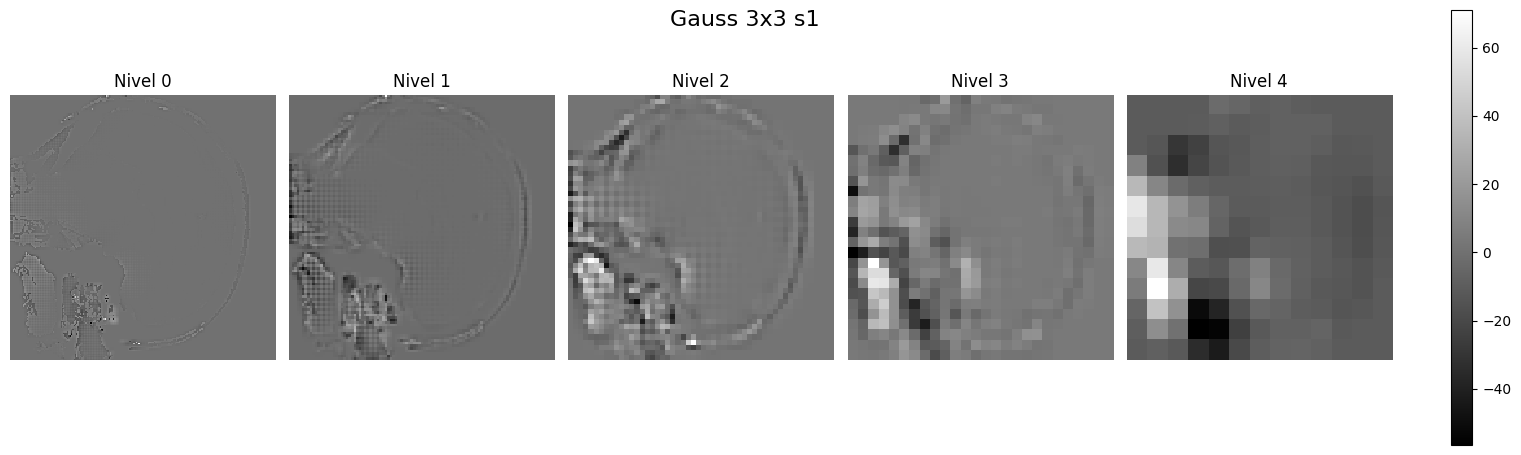

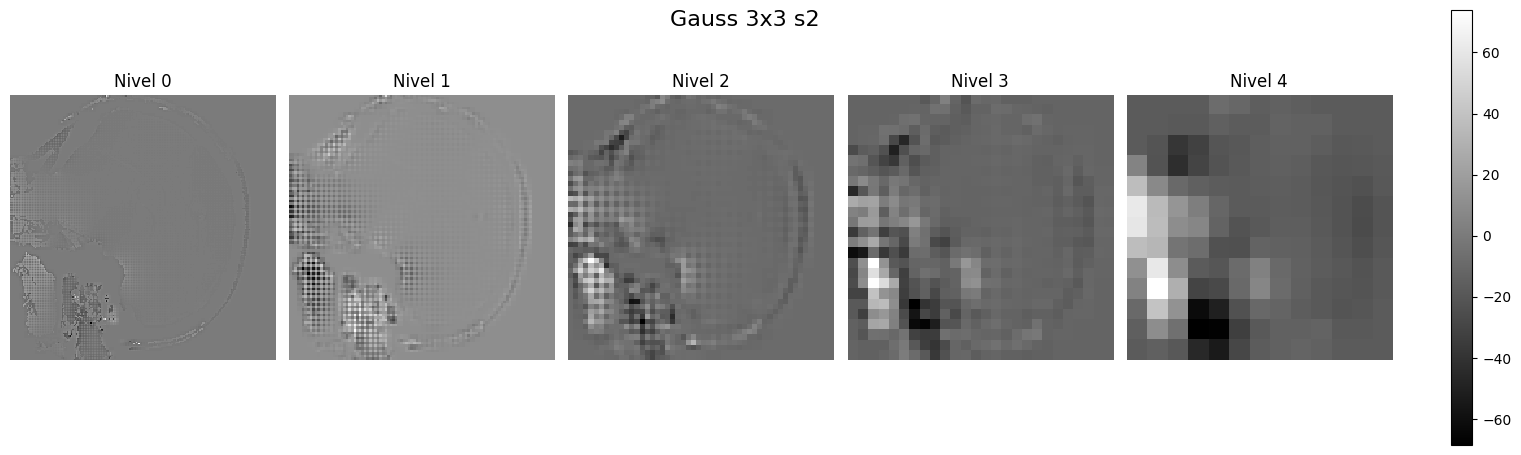

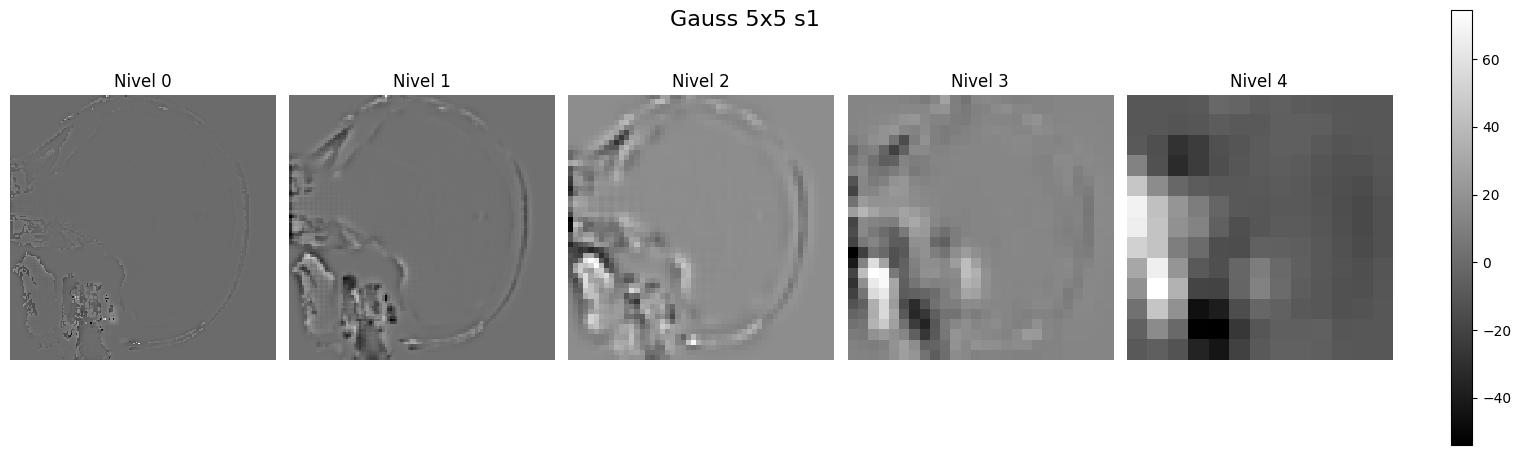

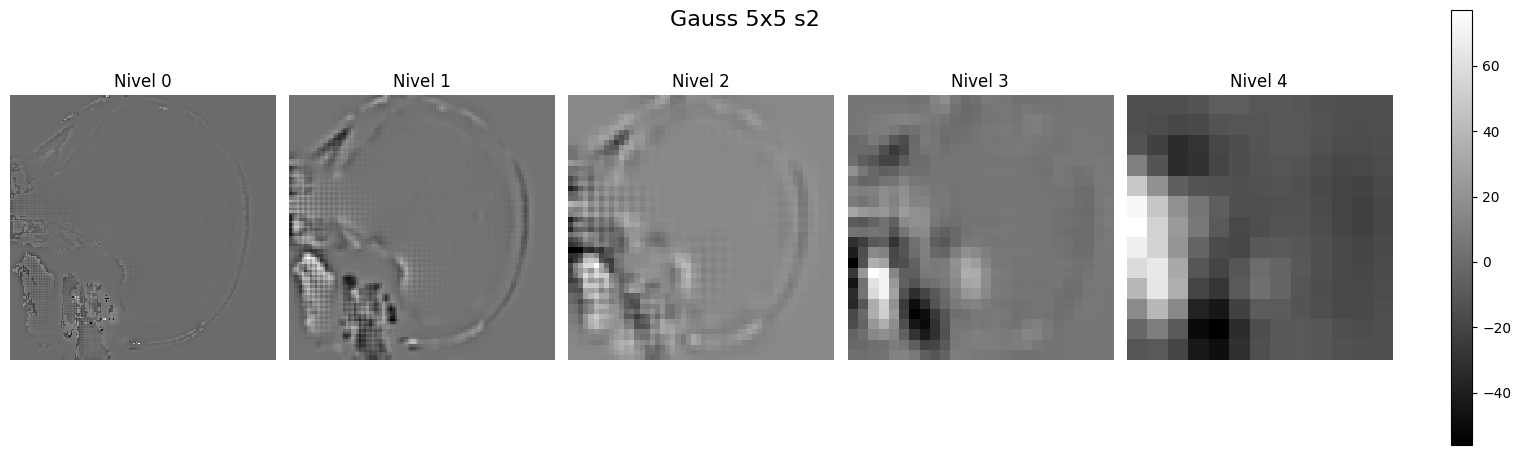

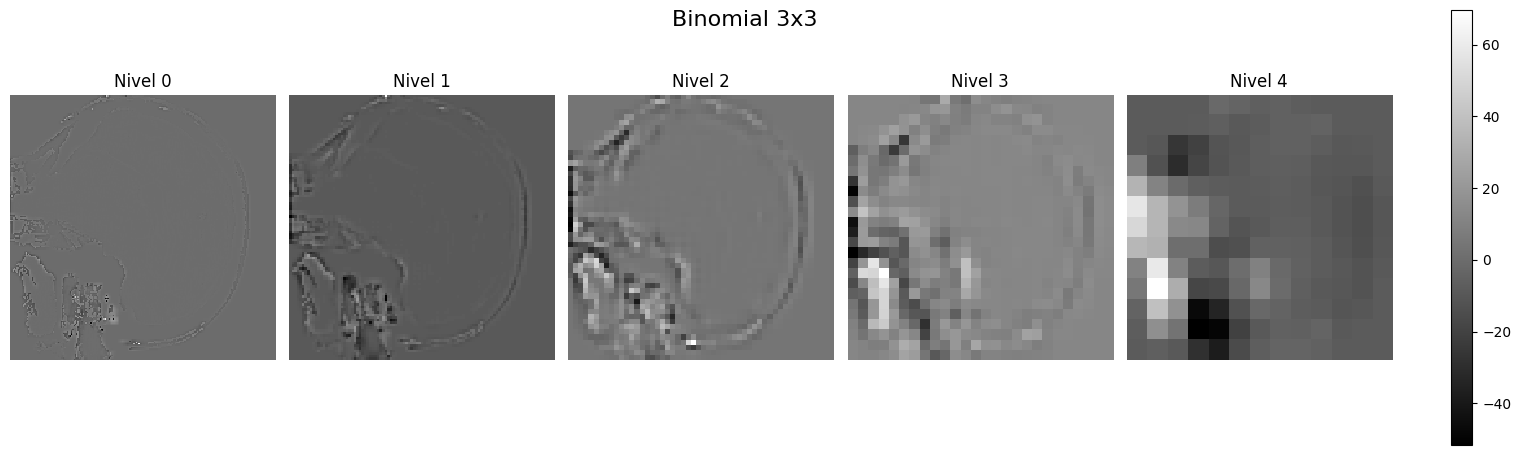

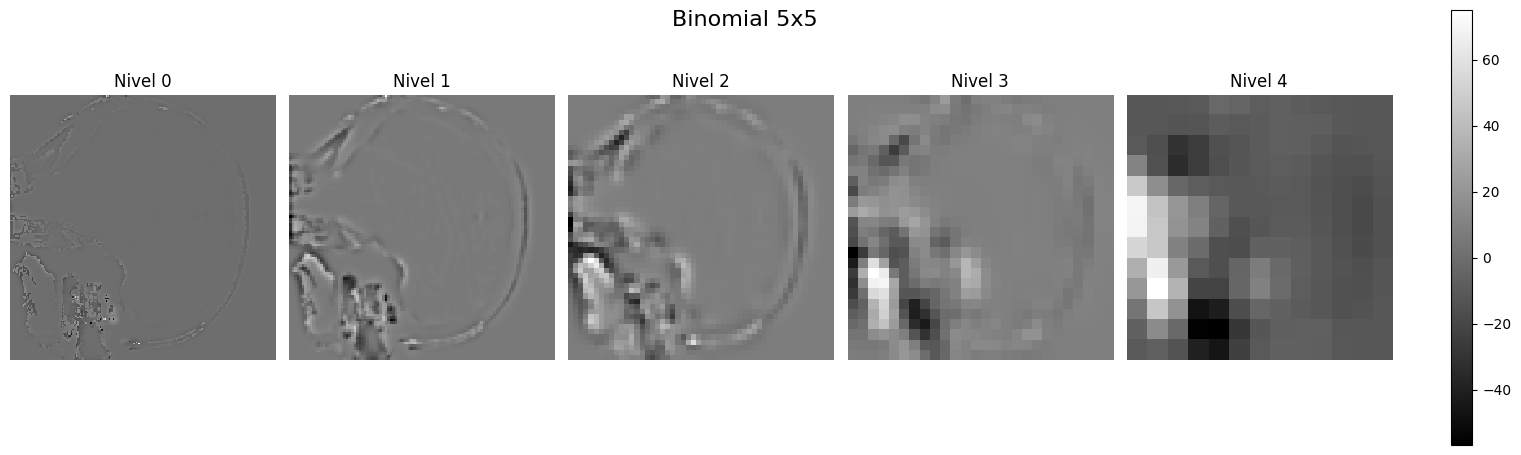

In [85]:
for name, lp, func in lp_pyramids_3d:
    show_pyramid_3d(lp, name)

In [86]:
print(f"{'Filtro':<18} {'Res FONDO':>12} {'Res LOCAL':>12}  {'Armónico':>15}")
print("-" * 65)

resultados = {}
for name, lp, func in lp_pyramids_3d:
    bg_filtered = func(fase_fondo)
    local_filtered = func(fase_local)

    diff_fondo = np.abs(fase_fondo - bg_filtered)[mask > 0]
    diff_local = np.abs(fase_local - local_filtered)[mask > 0]

    res_fondo = np.mean(diff_fondo)
    res_local = np.mean(diff_local)
    armonic = res_fondo < res_local # es armonico?

    resultados[name] = {
        "res_fondo": res_fondo,
        "res_local": res_local,
    }

    print(f"{name:<18} {res_fondo:>12.4f} {res_local:>12.4f}  {'TRUE' if armonic else 'FALSE':>15}")

Filtro                Res FONDO    Res LOCAL         Armónico
-----------------------------------------------------------------
AVG 3x3                  0.0218       0.0370             TRUE
AVG 5x5                  0.0316       0.0491             TRUE
Gauss 3x3 s1             0.0195       0.0324             TRUE
Gauss 3x3 s2             0.0213       0.0359             TRUE
Gauss 5x5 s1             0.0219       0.0363             TRUE
Gauss 5x5 s2             0.0285       0.0455             TRUE
Binomial 3x3             0.0185       0.0304             TRUE
Binomial 5x5             0.0227       0.0376             TRUE


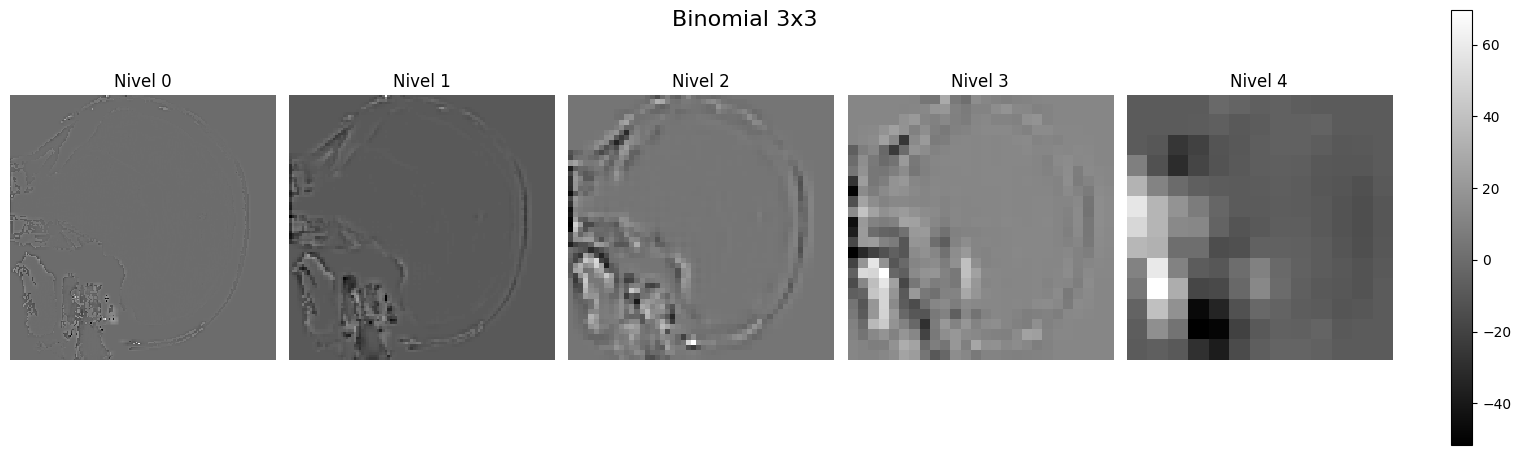

Véase la figura superior, donde la pirámide Laplaciana descompone la fase total en sus componentes: los niveles superiores capturan la fase local y el residual captura el campo de fondo armónico. Los filtros que mejor respetan la `Spherical Mean Value Property` midiendo cuánto modifica cada filtro el **fondo** versus la **fase local** son los `Binomiales` y los `Gaussianos` con sigma = 1.

#### 3.3) Analice si esta representación permite separar componentes armónicas de no armónicas. Justifique con visualizaciones (capas, reconstrucciones parciales, mapas, perfiles) (5 puntos)

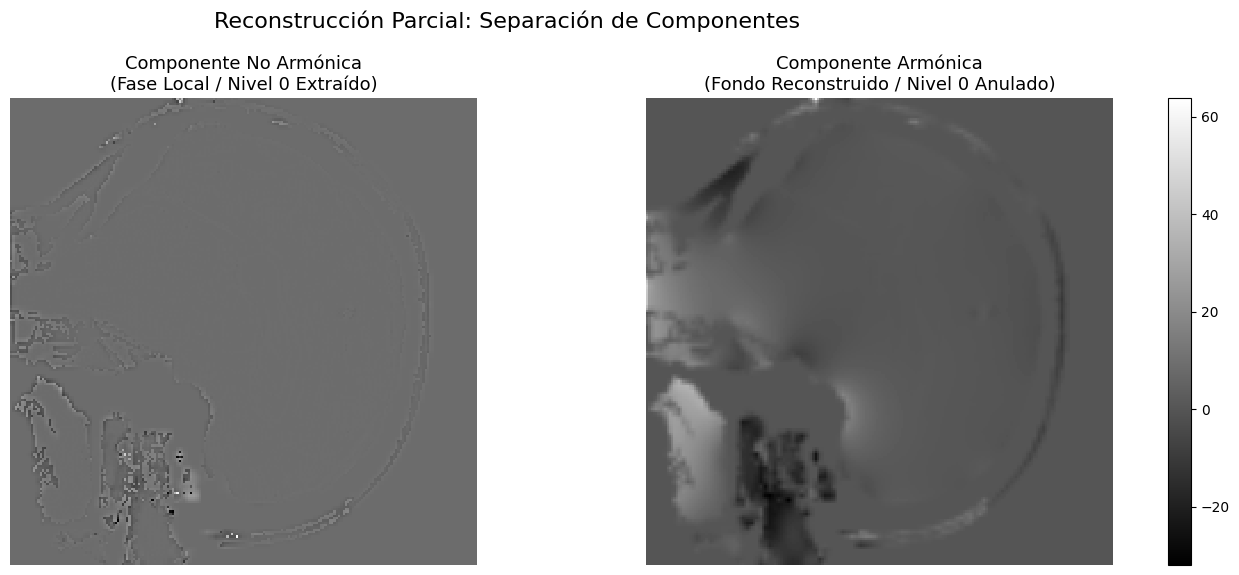

In [125]:
# Para el último entendí que se debe analizar si es posible separar componentes armónicos y no armónicos.
# Por eso mismo, tomo el primer nivel (0) de la pirámide Laplaciana, que es el que captura la fase local (no armónica) y lo vuelvo 0.
# Entonces, la idea es ver si es posible reconstruir parcialmente con esto.
pyramid_bg = lp_bin_3_3d.copy()
pyramid_bg[0] = np.zeros_like(pyramid_bg[0])
reconstructed_bg = reconstruct_3d(pyramid_bg, conv_bin_3_3d)
local_extraido = lp_bin_3_3d[0]

mid_slice = local_extraido.shape[0] // 2
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Reconstrucción Parcial: Separación de Componentes \n", fontsize=16, y=0.95)

im0 = axes[0].imshow(local_extraido[mid_slice], cmap='gray', interpolation='none')
axes[0].set_title("Componente No Armónica\n(Fase Local / Nivel 0 Extraído)", fontsize=13)
axes[0].axis('off')

im1 = axes[1].imshow(reconstructed_bg[mid_slice], cmap='gray', interpolation='none')
axes[1].set_title("Componente Armónica\n(Fondo Reconstruido / Nivel 0 Anulado)", fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.colorbar(im1, ax=axes, fraction=0.02, pad=0.04)
plt.show()

Véase la figura superior, donde se realiza una reconstrucción parcial anulando el nivel 0 (imagen de la derecha) obteniendo una imagen suave y continua. Este comportamiento afirmaría que esta representación es capaz de separar la fase local (no armónica) del fondo (armónico), cumpliendo la propiedad de valor medio esférico.